In [62]:
from dsc80_utils import *
import lec16_util as util

# Lecture 16 – Hyperparameters, Cross-Validation, and Decision Trees

## DSC 80, Winter 2026

### Agenda 📆

- Generalization.
    - Bias and variance.
    - Train-test splits.
- Hyperparameters.
- Cross-validation.
- Decision trees.

## Generalization

### Model Complexity

Last time, we looked at the following data set:

In [63]:
np.random.seed(23) # For reproducibility.

def sample_from_pop(n=100):
    x = np.linspace(-2, 3, n)
    y = x ** 3 + (np.random.normal(0, 3, size=n))
    return pd.DataFrame({'x': x, 'y': y})

past_data = sample_from_pop()
future_data = sample_from_pop()

In [64]:
px.scatter(past_data, x='x', y='y', title='Past Data')

- We trained three polynomial regression models of increasing **complexity**:
    - Degree 1 polynomial $H(x) = w_0 + w_1 x$
        - Straight line
    - Degree 3 polynomial $H(x) = w_0 + w_1 x + w_2 x^2 + w_3 x^3$
        - Cubic
    - Degree 25 polynomial $H(x) = w_0 + w_1 x + w_2 x^2 + \ldots + w_{24} x^{24} + w_{25}x^{25}$
        - Very wiggly curve

In [65]:
fig = util.train_and_plot(train_sample=past_data, test_sample=past_data, degs=[1, 3, 25], data_name='Past Data')
fig.update_layout(title='Trained on Past Data, Performance on Past Data')

- "Complex" models are more "flexible", so they are able to fit the training data better.
    - In theory, a degree 99 polynomial would be able to fit this data *exactly*.
- As the model becomes more "complex", the RMSE on the past data can only decrease.
    - This is a mathematical certainty!

## Future, Unseen Data

- Now imagine we get access to new, unseen data and use our already-trained models to make predictions.
- How well do they do?

In [66]:
fig = util.train_and_plot(train_sample=past_data, test_sample=future_data, degs=[1, 3, 25], data_name='Future Data')
fig.update_layout(title='Trained on Past Data, Performance on Unseen, Future Data')

- The most complex model (degree 25) is no longer the best!
- In short, it is "overfit" to the past data, and does not generalize well to new, unseen data.
- Meanwhile, the degree 1 polynomial is "underfit".

### Model variation

What if we trained models on both samples? How much would the fit models differ?

In [67]:
util.plot_multiple_models(past_data, future_data, degs=[1, 3, 25])

### Bias and variance

The training data we have access to is a sample from the population. We are concerned with our model's ability to **generalize** and work well on **different datasets** drawn from the same population.

Suppose we **fit** a model $H$ (e.g. a degree 3 polynomial) on **several different datasets** from the same population. There are three sources of error that arise:

* ⭐️ **Bias**: **The expected deviation between a predicted value and an actual value**.
    - In other words, **for a given $x_i$, how far is $H(x_i)$ from the true $y_i$, on average?**
    - Low bias is good! ✅
    - High bias is a sign of **underfitting**, i.e. that our model is too **basic** to capture the relationship between our features and response.

- ⭐️ **Model variance ("variance")**: **The variance of a model's predictions**.
    - In other words, **for a given $x_i$, how much does $H(x_i)$ vary across all datasets**?
    - Low model variance is good! ✅
    - High model variance is a sign of **overfitting**, i.e. that our model is too **complicated** and is prone to fitting to the noise in our training data.

- **Observation error**: The error due to the random noise in the process we are trying to model (e.g. measurement error). _We can't control this, without collecting more data!_

Here, suppose:
- The <span style='color:#c6283f'><b>red bulls-eye</b></span> represents an **actual tip** 💲.
- The <span style='color:#080c6f'><b>dark blue darts</b></span> represent **predictions of the tip** using different models that were fit on samples from the same data generating process. 
<br>

<center><img src="imgs/image_5.png" width="40%"></center>

We'd like our models to be in the top left, but in practice that's hard to achieve!

### Expected loss

- **Key idea**: A model that works well on past data should work well on future data, if future data looks like past data.

- What we really want is for the **expected loss for a new data point $(x_{\text{new}}, y_{\text{new}})$, drawn from the same population as the training set, to be small**. That is, we want
    $$\mathbb{E}[y_{\text{new}} - H(x_{\text{new}})]^2$$
    to be minimized. 

- $\mathbb{E}$ is the **expectation** operator of a random variable: it computes the **average value** of the random variable across its entire distribution.

### The bias-variance decomposition

Expected loss can be decomposed as follows:

$$\mathbb{E}[y_{\text{new}} - H(x_{\text{new}})]^2 = \text{model bias}^2 + \text{model variance} + \text{observation error}$$

- Remember, this expectation $\mathbb{E}$ is over the entire population of $x$s and $y$s: in real life, we don't know what this population distribution is, so we can't put actual numbers to this.

- If $H$ is too simple to capture the relationship between $x$s and $y$s in the population, $H$ will **underfit** to training sets and have **high bias**.

- If $H$ is overly complex, $H$ will **overfit** to training sets and have **high variance**, meaning it will change significantly from one training set to the next.

- Generally:
    - Training error reflects bias, **not variance**.
    - Test error reflects **both bias and variance**.

### Navigating the bias-variance tradeoff

$$\mathbb{E}[y_{\text{new}} - H(x_{\text{new}})]^2 = \text{model bias}^2 + \text{model variance} + \text{observation error}$$

- As we collect **more data** points (i.e. as $n$ increases):
    - **Model variance decreases.**
    - If $H$ can exactly model the true population relationship between $x$ and $y$ (e.g. cubic), then model bias also decreases.
    - If $H$ can't exactly model the true population relationship between $x$ and $y$, then model bias will remain large.

- As we add more **features** (i.e. as $d$ increases):
    - **Model variance increases**, whether or not the feature was useful.
    - Adding a useful feature decreases model bias.
    - Adding a useless feature doesn't change model bias.

- Example: suppose the actual relationship between $x$ and $y$ in the population is linear, and we fit $H$ using simple linear regression.
    - Model bias = 0.
    - Model variance is proportional to $\frac{d}{n}$.
        - As $d$ increases, model variance increases.
        - As $n$ increases, model variance decreases.

Read more [here](https://learningds.org/ch/17/inf_pred_gen_prob.html#probability-behind-model-selection).

## Train-test splits

### Avoiding overfitting

- We won't know whether our model has **overfit** to our sample (training data) unless we get to see how well it performs on a new sample from the same population.

- 💡**Idea**: **Split** our sample into a <span style='color: blue'><b>training set</b></span> that we use to fit our model (i.e. find $w^*$), and a <span style='color: orange'><b>test set</b></span> that we use to evaluate our model (e.g. RMSE, $R^2$).

- The test set is like a new sample of data from the same population as the training data!

<center><img src='imgs/train-test-first.png' width=40%></center>

### Train-test split 🚆

`sklearn.model_selection.train_test_split` implements a train-test split for us! 🙏🏼 

If `X` is an array/DataFrame of features and `y` is an array/Series of responses,

```py
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)
```

randomly splits the features and responses into training and test sets, such that the test set contains 0.25 of the full dataset.

In [68]:
from sklearn.model_selection import train_test_split

In [69]:
# Read the documentation!
# train_test_split?

Let's perform a train/test split on our polynomial dataset.

In [70]:
X = past_data[['x']]
y = past_data['y']

# Default behavior is to randomly split the data into 75% train, 25% test
# random_state is for reproducibility, like a random seed
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=100)

Let's check the sizes of `X_train` and `X_test`.

In [71]:
print('Rows in X_train:', X_train.shape[0])
print('Rows in X_test:', X_test.shape[0])

Rows in X_train: 75
Rows in X_test: 25


### Conducting train-test splits

- **Question**: _How_ should we split?
    - `sklearn`'s `train_test_split` splits **randomly**, which usually works well.
    - However, if there is some element of **time** in the training data (say, when predicting the future price of a stock), a better split is "past" and "future".

- **Question**: How _large_ should the split be, e.g. 90%-10% vs. 75%-25%?
    - There's a tradeoff – a larger training set should lead to a "better" model, while a larger test set should lead to a better estimate of our model's ability to generalize.
    - There's no "right" choice, but we usually choose between 10% and 25% for the test set.

## Hyperparameters

### Parameters vs. hyperparameters

- A **parameter** defines the relationship between variables in a model. 
    - **We learn parameters from data**.
    - For instance, suppose we fit a degree 3 polynomial to data, and end up with
    
    $$H(x) = 1 - 2x + 13x^2 - 4x^3$$
    
    - The coefficients $1$, $-2$, $13$, and $-4$ are the parameters.

- A **hyperparameter** is a parameter that we get to choose **before our model is fit to the data**.
    - Think of hyperparameters as knobs 🎛 – **we get to pick and tune them!**
    - **Polynomial degree** was a hyperparameter in the previous example, and we tried three different values: 1, 3, and 25.

- **Question**: How do we choose the "right" values for hyperparameters?

### Choosing hyperparameters

- We know that a model's performance on a test set is a good estimate of its ability to generalize to unseen data. We want to find the hyperparameter that leads to the best **test set performance**.

- Idea:
    1. Come up with a list of hyperparameters to try.
    2. For each choice of hyperparameter:
       - 1. train the model on the training set, and
       - 2. evaluate its performance on the test set.
    3. Pick the hyperparameter with the best performance on the test set.

- Why does this work?
    - We typically assume that future data will look like past data, but slightly different due to randomness.
    - In a random split of data, the test set looks like the training set without being the same.

### Polynomial degree vs. train/test error

Let's try this strategy on our earlier example. We'll create polynomial models of degree 1 through 25 and compute their train and test errors.

In [72]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

In [73]:
train_errs = []
test_errs = []

for d in range(1, 26):
    pl = make_pipeline(PolynomialFeatures(d), LinearRegression())
    pl.fit(X_train, y_train)
    train_errs.append(root_mean_squared_error(y_train, pl.predict(X_train)))
    test_errs.append(root_mean_squared_error(y_test, pl.predict(X_test)))

errs = pd.DataFrame({'Train Error': train_errs, 'Test Error': test_errs})

Let's look at the plots of training error vs. degree and test error vs. degree.

In [74]:
fig = px.line(errs)
fig.update_layout(showlegend=True, xaxis_title='Polynomial Degree', yaxis_title='RMSE')

- Training error appears to decrease as polynomial degree increases.

- Test error appears to decrease until a "valley", and then increases again.

- Here, we'd choose a degree of 3, since that degree has the **lowest test error**.

### Training error vs. test error

The pattern we saw in the previous example is true more generally.

<center><img src='imgs/tt-errors.png' width=50%></center>

We pick the hyperparameter(s) at the "valley" of test error.

Note that training error **tends** to underestimate test error, but it doesn't have to – i.e., it is possible for test error to be lower than training error (say, if the test set is "easier" to predict than the training set).

### But wait...

- With our current strategy, we are choosing the hyperparameter that creates the model that **performs best on the test set**.

- As such, we are **overfitting to the test set** – the best hyperparameter for the test set might not be the best hyperparameter for a totally unseen dataset!

- It seems like we need **another** split.

## Cross-validation

### Idea: further splitting

<center><img src='imgs/train-test-val.png' width=40%></center>

1. Split the data into three sets: <span style='color: blue'><b>training</b></span>, <span style='color: green'><b>validation</b></span>, and <span style='color: orange'><b>test</b></span>.

2. For each hyperparameter choice, <span style='color: blue'><b>train</b></span> the model only on the <span style='color: blue'><b>training set</b></span>, and <span style='color: green'><b>evaluate</b></span> the model's performance on the <span style='color: green'><b>validation set</b></span>.

3. Find the hyperparameter with the best <span style='color: green'><b>validation</b></span> performance.

4. Retrain the final model on the <span style='color: blue'><b>training</b></span> and <span style='color: green'><b>validation</b></span> sets, and report its performance on the <span style='color: orange'><b>test set</b></span>.

**Issue**: This strategy is too dependent on the <span style='color: green'><b>validation</b></span> set, which may be small and/or not a representative sample of the data. 
- We're not going to do this. ❌
- But it inspires the strategy we will use. 💡

### A better idea: $k$-fold cross-validation

Instead of relying on a single <span style='color: green'><b>validation</b></span> set, we can create $k$ <span style='color: green'><b>validation</b></span> sets, where $k$ is some positive integer (5 in the example below).

<center><img src='imgs/k-fold.png' width=40%></center>

Since each data point is used for <span style='color: blue'><b>training</b></span> $k-1$ times and <span style='color: green'><b>validation</b></span> once, the (averaged) <span style='color: green'><b>validation</b></span> performance should be a good metric of a model's ability to generalize to unseen data.

$k$-fold cross-validation (or simply "cross-validation") is **the** technique we will use for finding hyperparameters, or more generally, for choosing between different possible models. **It's what you should use in your Final Project!** ✅

### Creating folds in `sklearn`

`sklearn` has a `KFold` class that splits data into training and validation folds.

In [75]:
from sklearn.model_selection import KFold

Let's use a simple dataset for illustration.

In [76]:
data = np.arange(10, 70, 10)
data

array([10, 20, 30, 40, 50, 60])

Let's instantiate a `KFold` object with $k=3$.

In [77]:
kfold = KFold(3, shuffle=True)
kfold

KFold(n_splits=3, random_state=None, shuffle=True)

Finally, let's use `kfold` to `split` `data`:

In [78]:
for train, val in kfold.split(data):
    print(f'train: {data[train]}, validation: {data[val]}')

train: [20 30 50 60], validation: [10 40]
train: [10 20 40 60], validation: [30 50]
train: [10 30 40 50], validation: [20 60]


Note that each value in `data` is used for validation exactly once and for training exactly twice. Also note that because we set `shuffle=True` the folds are not simply `[10, 20]`, `[30, 40]`, and `[50, 60]`.

### $k$-fold cross-validation

First, **shuffle** the entire training set randomly and **split** it into $k$ disjoint folds, or "slices". Then:

- For each hyperparameter value:
    - For each slice:
        - Let the slice be the "validation set", $V$.
        - Let the rest of the data be the "training set", $T$.
        - Using the selected hyperparameter value, train a model on the training set $T$.
        - Evaluate the model on the validation set $V$.
    - Compute the **average** validation score (e.g. RMSE) for this hyperparameter value.

- Choose the hyperparameter value with the best average validation score.

### $k$-fold cross-validation in `sklearn`

While you could manually use `KFold` to perform cross-validation, the `cross_val_score` function in `sklearn` implements $k$-fold cross-validation for us! 

```py
cross_val_score(estimator, X_train, y_train, cv)
```

Specifically, it takes in:
- A `Pipeline` or estimator **that has not already been `fit`**.
- Training data.
- A value of $k$ (through the `cv` argument).
- (Optionally) A `scoring` metric.

and performs $k$-fold cross-validation, returning the values of the scoring metric on each fold.

In [79]:
from sklearn.model_selection import cross_val_score

In [80]:
# Read the documentation!
# cross_val_score?

### $k$-fold cross-validation in `sklearn`

- Let's perform $k$-fold cross validation in order to help us pick a degree for polynomial regression from the list [1, 2, ..., 25].

- We'll use $k=5$ since it's a common choice (and the default in `sklearn`).

In [81]:
errs_df = pd.DataFrame()

for d in range(1, 26):
    pl = make_pipeline(PolynomialFeatures(d), LinearRegression())
    
    # The `scoring` argument is used to specify that we want to compute the RMSE; 
    # the default is R^2. It's called "neg" RMSE because, 
    # by default, sklearn likes to "maximize" scores, and maximizing -RMSE is the same
    # as minimizing RMSE.
    errs = cross_val_score(pl, X_train[['x']], y_train, 
                           cv=5, scoring='neg_root_mean_squared_error')
    errs_df[f'Deg {d}'] = -errs # Negate to turn positive (sklearn computed negative RMSE).
    
errs_df.index = [f'Fold {i}' for i in range(1, 6)]
errs_df.index.name = 'Validation Fold'

Next class, we'll see an even better way to implement this procedure, without needing to `for`-loop over values of `d`.

### $k$-fold cross-validation in `sklearn`

Note that for each choice of degree (our hyperparameter), we have **five** RMSEs, one for each "fold" of the data. This means that in total, $5 \cdot 25 = 125$ models were trained/fit to data!

In [82]:
errs_df

,Deg 1,Deg 2,Deg 3,Deg 4,...,Deg 22,Deg 23,Deg 24,Deg 25
Validation Fold,,,,,,,,,
Fold 1,4.70,3.77,2.69,2.74,...,3.44,3.40,3.39,5.29
Fold 2,6.39,4.60,2.99,3.26,...,20.96,27.25,26.90,16.01
Fold 3,4.18,3.44,2.93,2.93,...,3.23,3.18,3.21,3.67
Fold 4,5.13,4.10,2.40,2.47,...,5.32,32.21,29.67,88.77
Fold 5,3.54,2.82,3.60,3.60,...,4.68,4.28,4.34,4.00


We should choose the degree with the lowest **average** validation RMSE.

In [83]:
errs_df.mean()

Deg 1      4.79
Deg 2      3.75
Deg 3      2.92
          ...  
Deg 23    14.06
Deg 24    13.50
Deg 25    23.55
Length: 25, dtype: float64

In [84]:
errs_df.mean().idxmin()

'Deg 3'

Note that if we didn't perform $k$-fold cross-validation, but instead just used a single validation set, we may have ended up with a different result:

In [85]:
errs_df.idxmin(axis=1)

Validation Fold
Fold 1    Deg 3
Fold 2    Deg 3
Fold 3    Deg 6
Fold 4    Deg 3
Fold 5    Deg 2
dtype: object

### Another example: Tips

- We've seen how to use $k$-fold cross-validation to select hyperparameters.
- We can also use the same techinique to determine which subset of features to use in our model.
- Let's try this out on the tips dataset by making one pipeline for each subset of features we may want to use in our model.

In [86]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder

As we should always do, we'll perform a train-test split on `tips` and will only use the training data for cross-validation.

In [87]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [88]:
X = tips.drop('tip', axis=1)
y = tips['tip']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [89]:
# A dictionary that maps names to Pipeline objects.
select = FunctionTransformer(lambda x: x)
pipes = {
    'total_bill only': make_pipeline(
        make_column_transformer( (select, ['total_bill']) ),
        LinearRegression(),
    ),
    'total_bill + size': make_pipeline(
        make_column_transformer( (select, ['total_bill', 'size']) ),
        LinearRegression(),
    ),
    'total_bill + size + OHE smoker': make_pipeline(
        make_column_transformer(
            (select, ['total_bill', 'size']),
            (OneHotEncoder(drop='first'), ['smoker']),
        ),
        LinearRegression(),
    ),
    'total_bill + size + OHE all': make_pipeline(
        make_column_transformer(
            (select, ['total_bill', 'size']),
            (OneHotEncoder(drop='first'), ['smoker', 'sex', 'time', 'day']),
        ),
        LinearRegression(),
    ),
}

In [90]:
pipe_df = pd.DataFrame()

for pipe in pipes:
    errs = cross_val_score(pipes[pipe], X_train, y_train,
                           cv=5, scoring='neg_root_mean_squared_error')
    pipe_df[pipe] = -errs
    
pipe_df.index = [f'Fold {i}' for i in range(1, 6)]
pipe_df.index.name = 'Validation Fold'

In [91]:
pipe_df

,total_bill only,total_bill + size,total_bill + size + OHE smoker,total_bill + size + OHE all
Validation Fold,,,,
Fold 1,1.32,1.27,1.27,1.29
Fold 2,0.95,0.92,0.93,0.93
Fold 3,0.77,0.86,0.86,0.87
Fold 4,0.85,0.84,0.84,0.86
Fold 5,1.10,1.07,1.07,1.08


In [92]:
pipe_df.mean()

total_bill only                   1.00
total_bill + size                 0.99
total_bill + size + OHE smoker    0.99
total_bill + size + OHE all       1.01
dtype: float64

In [93]:
pipe_df.mean().idxmin()

'total_bill + size + OHE smoker'

Even though the third model has the lowest average validation RMSE, its average validation RMSE is very close to that of the other, simpler models, and as a result we'd likely use the simplest model in practice.

<div class="alert alert-warning">
    <h3>Question 🤔</h3>
</div>

- Suppose you have a training dataset with 1000 rows.
- You want to decide between 20 hyperparameters for a particular model.
- To do so, you perform 10-fold cross-validation.
- **How many times is the first row in the training dataset (`X.iloc[0]`) used for training a model?**


### The modeling process

1. Split the data into two sets: <span style='color: blue'><b>training</b></span> and <span style='color: orange'><b>test</b></span>.

2. Use only the <span style='color: blue'><b>training</b></span> data when designing, training, and tuning the model.
    - Use <span style='color: green'><b>$k$-fold cross-validation</b></span> to choose hyperparameters and estimate the model's ability to generalize.
    - Do not look at the <span style='color: orange'><b>test</b></span> data in this step! 🙈

3. Commit to your final model and train it using the entire <span style='color: blue'><b>training</b></span> set.

4. Test the data using the <span style='color: orange'><b>test</b></span> data. If the performance (e.g. RMSE) is not acceptable, return to step 2.

5. Finally, train on **all available data** and ship the model to production! 🛳

🚨 This is the process you should **always** use! 🚨 

## Decision trees 🌲

<center><img src='imgs/ml-taxonomy.svg' width=50%></center>

Decision trees can be used for both regression and classification. We'll start by using them for **classification**.

### Example: Should I get groceries?

Decision trees make classifications by answering a series of yes/no questions.

**Should I go to Trader Joe's to buy groceries today?**

<center><img src='imgs/dtree-basic.svg' width=400></center>

Internal **nodes** of trees involve questions; leaf nodes make predictions $H(x)$.

<center><img src='imgs/dtree-basic-plot.svg' width=400></center>

### Example: Predicting diabetes

In [94]:
diabetes = pd.read_csv(Path('data') / 'diabetes.csv')
display_df(diabetes, cols=9)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.63,50,1
1,1,85,66,29,0,26.6,0.35,31,0
2,8,183,64,0,0,23.3,0.67,32,1
...,...,...,...,...,...,...,...,...,...
765,5,121,72,23,112,26.2,0.24,30,0
766,1,126,60,0,0,30.1,0.35,47,1
767,1,93,70,31,0,30.4,0.32,23,0


In [95]:
# 0 means no diabetes, 1 means yes diabetes.
diabetes['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

- `'Glucose'` is measured in mg/dL (milligrams per deciliter).

- `'BMI'` is calculated as $\text{BMI} = \frac{\text{weight (kg)}}{\left[ \text{height (m)} \right]^2}$.

- Let's use `'Glucose'` and `'BMI'` to predict whether or not a patient has diabetes (`'Outcome'`).

### Exploring the dataset

First, a train-test split:

In [96]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = (
    train_test_split(diabetes[['Glucose', 'BMI']], diabetes['Outcome'], random_state=1)
)

<span style='color: orange'><b>Class 0 (orange) is "no diabetes"</b></span> and <span style='color: blue'><b>class 1 (blue) is "diabetes"</b></span>.

In [97]:
fig = (
    X_train.assign(Outcome=y_train.astype(str))
            .plot(kind='scatter', x='Glucose', y='BMI', color='Outcome', 
                  color_discrete_map={'0': 'orange', '1': 'blue'},
                  title='Relationship between Glucose, BMI, and Diabetes')
)
fig

### Building a decision tree

Let's build a decision tree and interpret the results.

The relevant class is `DecisionTreeClassifier`, from `sklearn.tree`.

In [98]:
from sklearn.tree import DecisionTreeClassifier

Note that we `fit` it the same way we `fit` earlier estimators.

_You may wonder what `max_depth` and `criterion` do. These are hyperparameters – we'll see what they mean soon!_

In [99]:
dt = DecisionTreeClassifier(max_depth=2, criterion='entropy')

In [100]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=2)

### Visualizing decision trees

Our fit decision tree is like a "flowchart", made up of a series of questions.

As before, <span style='color: orange'><b>orange is "no diabetes"</b></span> and <span style='color: blue'><b>blue  is "diabetes"</b></span>.

In [101]:
from sklearn.tree import plot_tree

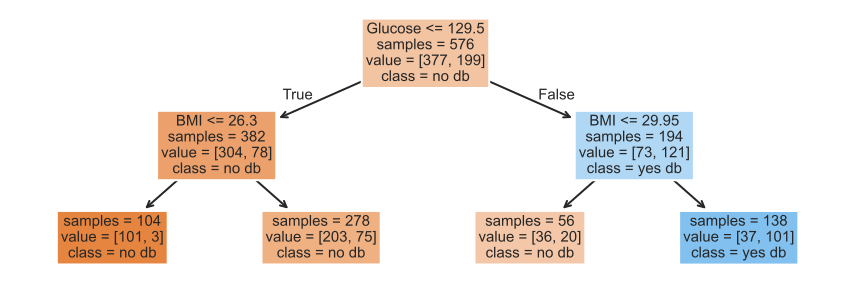

In [102]:
plt.figure(figsize=(15, 5))
plot_tree(dt, feature_names=X_train.columns, class_names=['no db', 'yes db'], 
          filled=True, fontsize=15, impurity=False);

- To **classify a new data point**, we start at the top and answer the first question (i.e. "Glucose <= 129.5").

- If the answer is "**Yes**", we move to the **left** branch, otherwise we move to the right branch.

- We repeat this process until we end up at a leaf node, at which point we predict the most common class in that node.
    - Note that each node has a `value` attribute, which describes the number of **training** individuals of each class that fell in that node.

In [103]:
# Note that the left node at depth 2 has a `value` of [304, 78].
y_train[X_train.query('Glucose <= 129.5').index].value_counts()

Outcome
0    304
1     78
Name: count, dtype: int64

### Evaluating classifiers

The most common evaluation metric in classification is **accuracy**:

$$\text{accuracy} = \frac{\text{\# data points classified correctly}}{\text{\# data points}}$$

In [104]:
(dt.predict(X_train) == y_train).mean()

0.765625

The `score` method of a classifier computes accuracy by default (just like the `score` method of a regressor computes $R^2$ by default). We want our classifiers to have **high accuracy**.

In [105]:
# Training accuracy – same number as above
dt.score(X_train, y_train)

0.765625

In [106]:
# Testing accuracy
dt.score(X_test, y_test)

0.7760416666666666

### Reflection

- Decision trees are easily interpretable: it is clear _how_ they make their predictions.

- They work with categorical data without needing to use one hot encoding.

- They also can be used in multi-class classification problems, e.g. when there are more than 2 possible outcomes.

- The _decision boundary_ of a decision tree can be arbitrarily complicated.

- **How are decision trees trained?**

### How are decision trees trained?

Pseudocode:

```python
def make_tree(X, y):
    if all points in y have the same label C:
        return Leaf(C)
    f = best splitting feature # e.g. Glucose or BMI
    v = best splitting value   # e.g. 129.5
    
    X_left, y_left   = X, y where (X[f] <= v)
    X_right, y_right = X, y where (X[f] > v)
    
    left  = make_tree(X_left, y_left)
    right = make_tree(X_right, y_right)
    
    return Node(f, v, left, right)
    
make_tree(X_train, y_train)
```

### How do we measure the quality of a split?

Our pseudocode for training a decision tree relies on finding the best way to "split" a node – that is, **the best question to ask** to help us narrow down which class to predict.

**Intuition**: Suppose the distribution within a node looks like this (colors represent classes):

<center>🟠🟠🟠🟠🟠🟠🔵🔵🔵🔵🔵🔵🔵</center>

Split A:
- "Yes": 🟠🟠🟠🔵🔵🔵
- "No": 🟠🟠🟠🔵🔵🔵🔵

Split B:
- "Yes": 🔵🔵🔵🔵🔵🔵
- "No": 🔵🟠🟠🟠🟠🟠🟠

**Which split is "better"?**

Split B, because there is "less uncertainty" in the resulting nodes in Split B than there is in Split A. Let's try and quantify this!

### Entropy

- For each class $C$ within a node, define $p_C$ as the proportion of points with that class.
    - For example, the two classes may be "yes diabetes" and "no diabetes".

- The **surprise** of drawing a point from the node at random and having it be class $C$ is:

$$
\log_2 \left(\frac{1}{p_C}\right) = - \log_2 p_C
$$

- The **entropy** of a node is the expected (average) surprise over all classes:

\begin{align}
\text{entropy} &= - \sum_C p_C \log_2 p_C
\end{align}

- The entropy of 🟠🟠🟠🟠🟠🟠🟠🟠 is $ -1 \log_2(1) = 0 $.

- The entropy of 🟠🟠🟠🟠🔵🔵🔵🔵 is $ -0.5 \log_2(0.5) - 0.5 \log_2(0.5) = 1$.

- The entropy of 🟠🔵🟢🟡🟣 is $ - \log_2 \frac{1}{5} = \log_2(5) $
    - In general, if a node has $n$ points, all with different labels, the entropy of the node is $ \log_2(n) $.

### Example entropy calculation

Suppose we have:

<center>🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🔵🔵🔵🔵🔵🔵</center>

Split A:
- "Yes": 🟠🟠🟠🟠🟠🟠🔵
- "No": 🟠🟠🟠🟠🟠🟠🔵🔵🔵🔵🔵

Split B:
- "Yes": 🟠🟠🟠🟠🟠🟠🔵🔵🔵
- "No": 🟠🟠🟠🟠🟠🟠🔵🔵🔵

We choose the split that has the lowest **weighted entropy**, that is:

$$\text{entropy of split} = \frac{\# \text{Yes}}{\# \text{Yes} + \# \text{No}} \cdot \text{entropy(Yes)} + \frac{\# \text{No}}{\# \text{Yes} + \# \text{No}} \cdot \text{entropy(No)}$$

In [107]:
def entropy(node):
    props = pd.Series(list(node)).value_counts(normalize=True)
    return -sum(props * np.log2(props))

In [108]:
entropy("🟠🟠🟠🟠🟠🟠🔵")

0.5916727785823275

In [109]:
def weighted_entropy(yes_node, no_node):
    yes_entropy = entropy(yes_node)
    no_entropy = entropy(no_node)
    yes_weight = len(yes_node) / (len(yes_node) + len(no_node))
    no_weight = 1 - yes_weight
    return yes_weight * yes_entropy + (no_weight) * no_entropy

In [110]:
# Split A:
weighted_entropy("🟠🟠🟠🟠🟠🟠🔵", "🟠🟠🟠🟠🟠🟠🔵🔵🔵🔵🔵")

0.8375578764623786

In [111]:
# Split B:
weighted_entropy("🟠🟠🟠🟠🟠🟠🔵🔵🔵", "🟠🟠🟠🟠🟠🟠🔵🔵🔵")

0.9182958340544896

Split A has the lower weighted entropy, so we'll use it.

### Understanding entropy

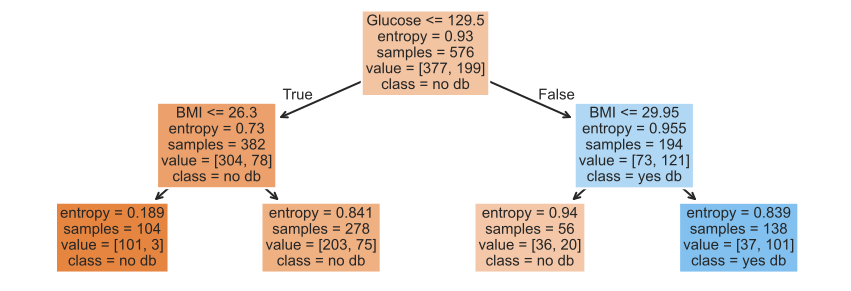

In [112]:
plt.figure(figsize=(15, 5))
plot_tree(dt, feature_names=X_train.columns, class_names=['no db', 'yes db'], 
          filled=True, fontsize=15, impurity=True);

We can recreate the entropy calculations above! Note that the default `DecisionTreeClassifier` uncertaintly metric _isn't_ entropy; it used entropy because we set `criterion='entropy'` when defining `dt`. (The default metric, [Gini impurity](https://en.wikipedia.org/wiki/Decision_tree_learning#:~:text=Gini%20impurity%20measures%20how%20often,into%20a%20single%20target%20category.), is perfectly fine too!)

In [113]:
# The leftmost node at the middle level has an entropy of 0.73,
# both told to us above and verified here!
entropy([0] * 304 + [1] * 78)

0.7302263747422792

### Tree depth

Decision trees are trained by **recursively** picking the best split until:

- all "leaf nodes" only contain training examples from a single class (good), or
- it is impossible to split leaf nodes any further (not good).

By default, there is no "maximum depth" for a decision tree. As such, without restriction, decision trees tend to be very deep.

In [114]:
dt_no_max = DecisionTreeClassifier()
dt_no_max.fit(X_train, y_train)

DecisionTreeClassifier()

A decision tree fit on our training data has a depth of around 20! (It is so deep that `tree.plot_tree` errors when trying to plot it.)

In [115]:
dt_no_max.tree_.max_depth

18

At first, this tree seems "better" than our tree of depth 2, since its training accuracy is much much higher:

In [116]:
dt_no_max.score(X_train, y_train)

0.9913194444444444

In [117]:
# Depth 2 tree.
dt.score(X_train, y_train)

0.765625

But recall, we truly care about **test set performance**, and this decision tree has **worse accuracy on the test set than our depth 2 tree**.

In [118]:
dt_no_max.score(X_test, y_test)

0.7083333333333334

In [119]:
# Depth 2 tree.
dt.score(X_test, y_test)

0.7760416666666666

### Decision trees and overfitting

- Decision trees have a tendency to overfit. **Why is that?**

- Unlike linear classification techniques (like logistic regression or SVMs), **decision trees are non-linear**.
    - They are also "non-parametric" – there are no $w^*$s to learn.

- While being trained, decision trees ask enough questions to effectively **memorize** the correct response values in the training set. However, the relationships they learn are often **overfit** to the noise in the training set, and don't generalize well.

In [120]:
fig

- A decision tree whose depth is not restricted will achieve 100% accuracy on any training set, as long as there are no "overlapping values" in the training set.
    - Two values overlap when they have the same features $x$ but different response values $y$ (e.g. if two patients have the same glucose levels and BMI, but one has diabetes and one doesn't).

- **One solution**: Make the decision tree "less complex" by limiting the maximum depth.

Since `sklearn.tree`'s `plot_tree` can't visualize extremely large decision trees, let's create and visualize some smaller decision trees.

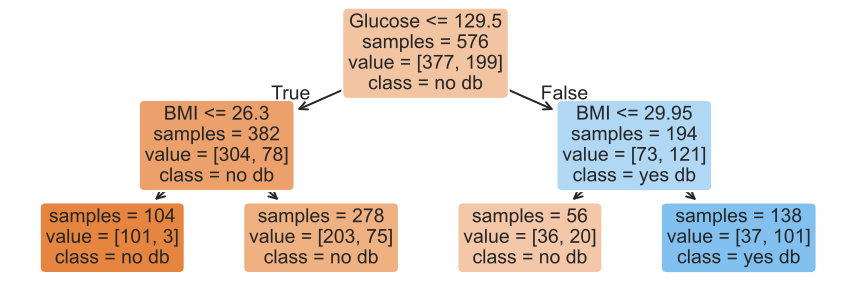

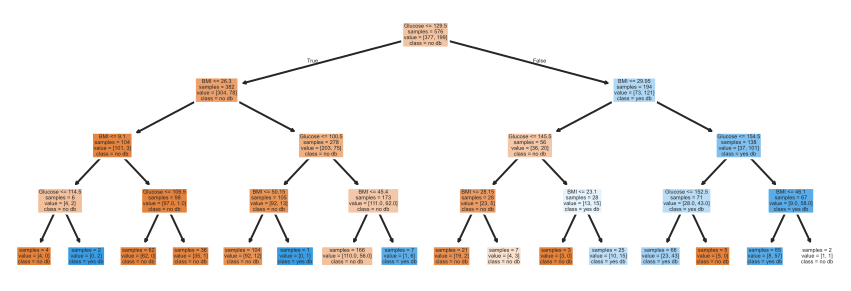

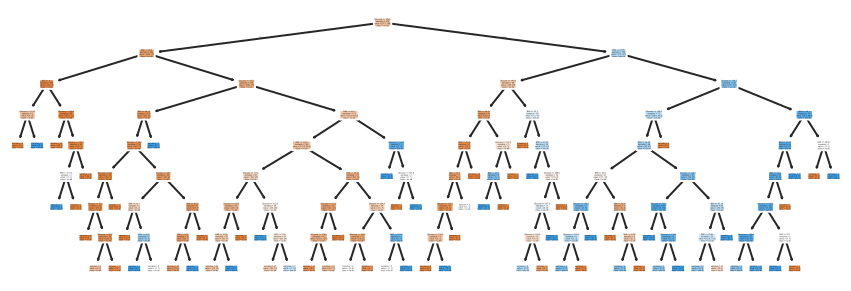

In [121]:
trees = {}
for d in [2, 4, 8]:
    trees[d] = DecisionTreeClassifier(max_depth=d, random_state=1)
    trees[d].fit(X_train, y_train)
    
    plt.figure(figsize=(15, 5), dpi=100)
    plot_tree(trees[d], feature_names=X_train.columns, class_names=['no db', 'yes db'], 
               filled=True, rounded=True, impurity=False)
    
    plt.show()

As tree depth increases, complexity increases, and our trees are more prone to overfitting. This means model bias decreases, but model variance increases. 

**Question**: What is the "right" maximum depth to choose?

### Hyperparameters for decision trees

- `max_depth` is a hyperparameter for `DecisionTreeClassifier`.

- There are many more hyperparameters we can tweak; look at [the documentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) for examples.
    - `min_samples_split`: The minimum number of samples required to split an internal node.
    - `criterion`: The function to measure the quality of a split (`'gini'` or `'entropy'`).

- To ensure that our model generalizes well to unseen data, we need an efficient technique for trying different combinations of hyperparameters!

- We'll see that technique next time: `GridSearchCV`.

<div class="alert alert-warning">
    <h3>Question 🤔</h3>
</div>


(From Fa23 Final)

Suppose we fit decision trees of varying depths to predict 'y' using 'x1' and 'x2'. The entire training set is shown in the table below.

<center><img src='https://practice.dsc80.com/assets/images/fa23-final/dsc_80_final_q10.png' width=15%></center>

What is:

1. The entropy of a node containing all the training points.
1. The lowest possible entropy of a node in a fitted tree with depth 1 (two leaf nodes).
1. The lowest possible entropy of a node in a fitted tree with depth 2 (four leaf nodes).

## Summary, next time

### Summary

- A hyperparameter is a configuration that we choose before training a model; an important task in machine learning is selecting "good" hyperparameters.
- To choose hyperparameters, we use $k$-fold cross-validation. **This technique is standard, and you are expected to use it in the Final Project!**
- Decision trees can be used for both regression and classification; we've used them for classification.
    - Decision trees are trained recursively. Each node corresponds to a "yes" or "no" question.
    - To decide which "yes" or "no" question to ask, we choose the question with the lowest weighted entropy.

### Next time

- An efficient technique for trying different combinations of hyperparameters.
    - In other words, performing $k$-fold cross-validation _without_ a `for`-loop.
- Techniques for evaluating classifiers beyond accuracy.
    - You'll need this for the Final Project!